In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

data = pd.read_csv(url, names=columns)

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

data.head()

Dataset loaded successfully!
Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

data = pd.read_csv(url, names=columns)

print("Dataset loaded successfully!")
data.head()

Dataset loaded successfully!


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
print("Dataset Shape:", data.shape)

Dataset Shape: (768, 9)


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Outcome
0    500
1    268
Name: count, dtype: int64


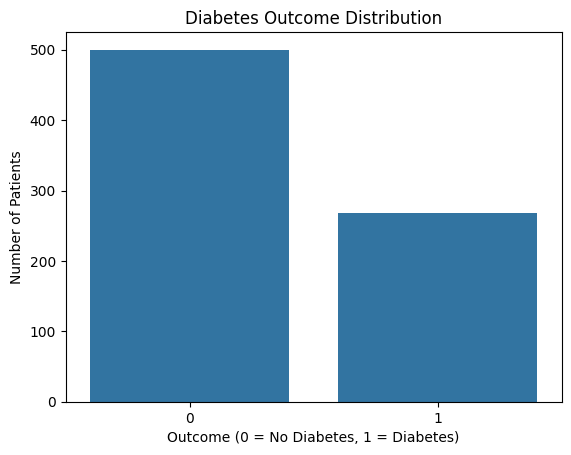

In [10]:
print(data["Outcome"].value_counts())

sns.countplot(x="Outcome", data=data)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")
plt.show()

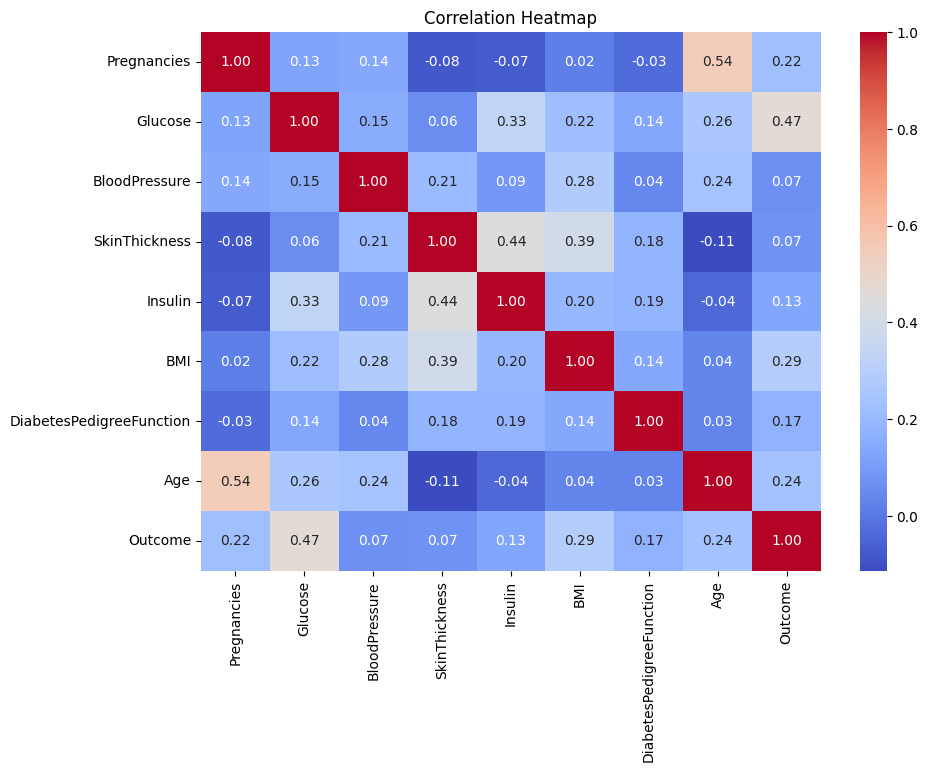

In [11]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [12]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [15]:
# STEP 13 - Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(
    X_train_scaled,
    y_train
)

# Make predictions
y_pred_lr = logistic_model.predict(X_test_scaled)

# Get prediction probabilities
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [16]:
print("First 10 Predictions:")
print(y_pred_lr[:10])

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

First 10 Predictions:
[1 0 0 0 0 0 0 1 0 1]

First 10 Actual Values:
[0 0 0 1 0 0 1 1 0 0]


In [17]:
# STEP 14 - Logistic Regression Evaluation

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("=" * 45)
print("   LOGISTIC REGRESSION RESULTS")
print("=" * 45)

print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")

print("=" * 45)

   LOGISTIC REGRESSION RESULTS
Accuracy  : 0.7143
Precision : 0.6087
Recall    : 0.5185
F1-Score  : 0.5600
ROC-AUC   : 0.8230


In [18]:
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["No Diabetes", "Diabetes"]
    )
)

Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.76      0.82      0.79       100
    Diabetes       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



Confusion Matrix:
[[82 18]
 [26 28]]


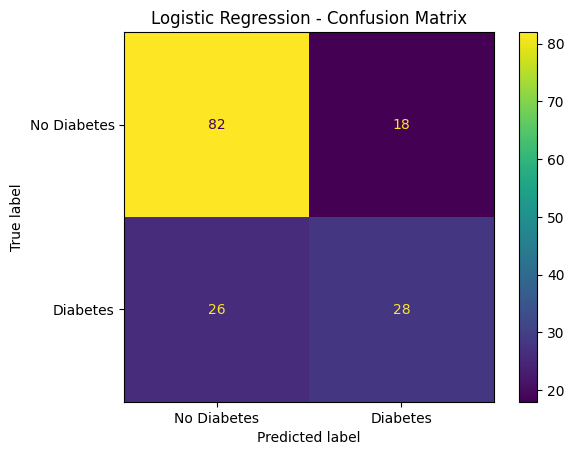

In [19]:
# STEP 15 - Confusion Matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [20]:
# STEP 16 - Random Forest

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(
    X_train,
    y_train
)

# Make predictions
y_pred_rf = random_forest.predict(X_test)

# Get prediction probabilities
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [21]:
print("First 10 Random Forest Predictions:")
print(y_pred_rf[:10])

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

First 10 Random Forest Predictions:
[1 0 0 0 0 0 0 1 0 1]

First 10 Actual Values:
[0 0 0 1 0 0 1 1 0 0]


In [22]:
# STEP 17 - Random Forest Evaluation

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=" * 45)
print("      RANDOM FOREST RESULTS")
print("=" * 45)

print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

print("=" * 45)

      RANDOM FOREST RESULTS
Accuracy  : 0.7597
Precision : 0.6809
Recall    : 0.5926
F1-Score  : 0.6337
ROC-AUC   : 0.8118


In [23]:
print("Random Forest Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["No Diabetes", "Diabetes"]
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.79      0.85      0.82       100
    Diabetes       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



Random Forest Confusion Matrix:
[[85 15]
 [22 32]]


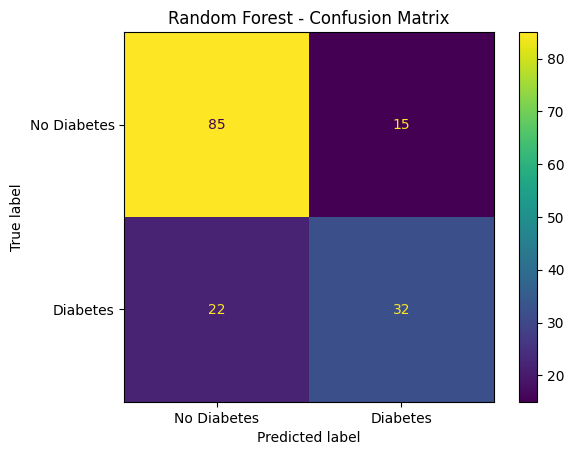

In [24]:
# STEP 18 - Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [25]:
# STEP 19 - Support Vector Machine (SVM)

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

# Train SVM using scaled data
svm_model.fit(
    X_train_scaled,
    y_train
)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Get prediction probabilities
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM model trained successfully!")

SVM model trained successfully!


In [26]:
print("First 10 SVM Predictions:")
print(y_pred_svm[:10])

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

First 10 SVM Predictions:
[1 0 0 0 0 0 0 1 0 1]

First 10 Actual Values:
[0 0 0 1 0 0 1 1 0 0]


In [27]:
# STEP 20 - SVM Evaluation

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print("=" * 45)
print("           SVM RESULTS")
print("=" * 45)

print(f"Accuracy  : {accuracy_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"F1-Score  : {f1_svm:.4f}")
print(f"ROC-AUC   : {roc_auc_svm:.4f}")

print("=" * 45)

           SVM RESULTS
Accuracy  : 0.7532
Precision : 0.6600
Recall    : 0.6111
F1-Score  : 0.6346
ROC-AUC   : 0.7924


In [28]:
print("SVM Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["No Diabetes", "Diabetes"]
    )
)

SVM Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



SVM Confusion Matrix:
[[83 17]
 [21 33]]


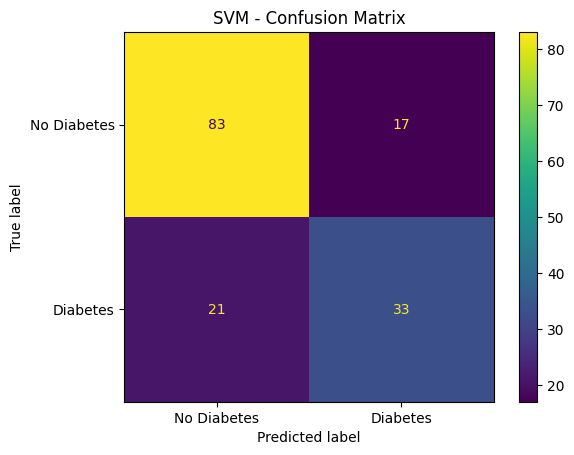

In [29]:
# STEP 21 - SVM Confusion Matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("SVM Confusion Matrix:")
print(cm_svm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()

plt.title("SVM - Confusion Matrix")
plt.show()

In [30]:
# STEP 22 - Model Comparison

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_svm
    ],

    "Precision": [
        precision_lr,
        precision_rf,
        precision_svm
    ],

    "Recall": [
        recall_lr,
        recall_rf,
        recall_svm
    ],

    "F1-Score": [
        f1_lr,
        f1_rf,
        f1_svm
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_svm
    ]
})

print("MODEL COMPARISON")
print("=" * 80)

display(results)

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.714286,0.608696,0.518519,0.560000,0.822963
1,Random Forest,0.759740,0.680851,0.592593,0.633663,0.811759
2,SVM,0.753247,0.660000,0.611111,0.634615,0.792407


In [31]:
# Find the model with the highest ROC-AUC

best_model_name = results.loc[
    results["ROC-AUC"].idxmax(),
    "Model"
]

best_roc_auc = results["ROC-AUC"].max()

print("=" * 50)
print("           BEST MODEL")
print("=" * 50)

print("Best Model :", best_model_name)
print(f"ROC-AUC    : {best_roc_auc:.4f}")

print("=" * 50)

           BEST MODEL
Best Model : Logistic Regression
ROC-AUC    : 0.8230


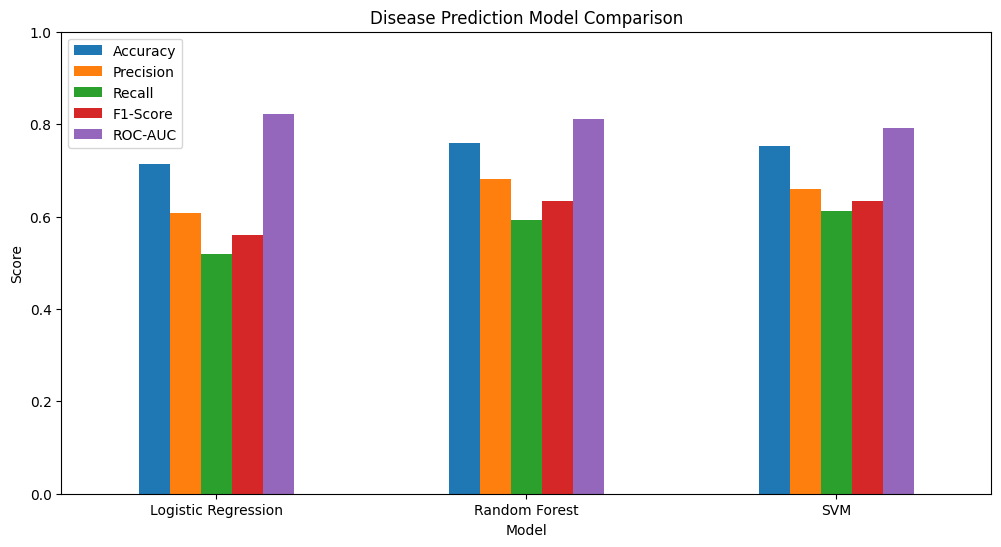

In [32]:
# Model Performance Comparison Graph

results.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Disease Prediction Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

<Figure size 1000x700 with 0 Axes>

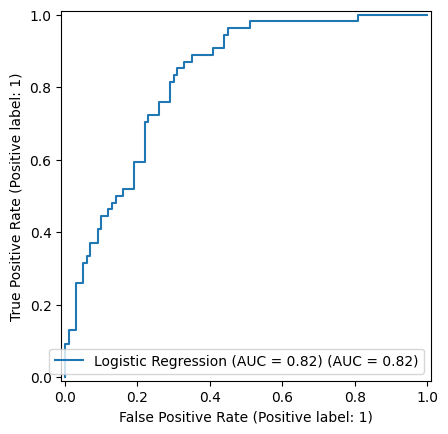

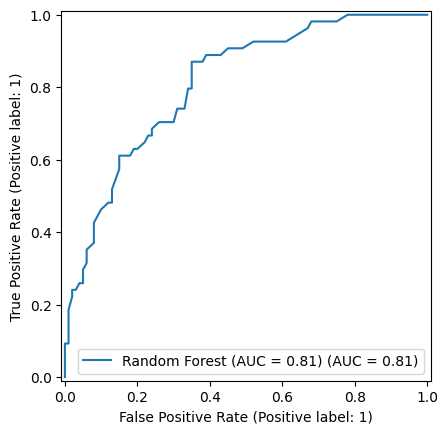

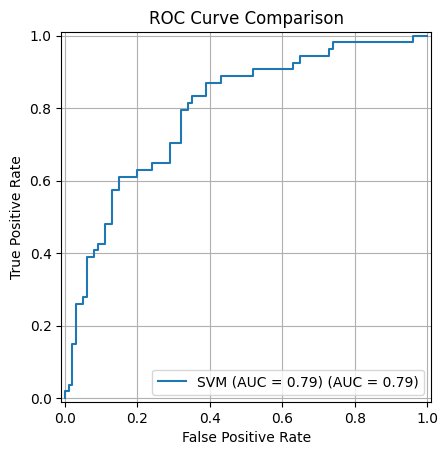

In [33]:
# STEP 23 - ROC Curve Comparison

plt.figure(figsize=(10, 7))

# Logistic Regression
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name=f"Logistic Regression (AUC = {roc_auc_lr:.2f})"
)

# Random Forest
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name=f"Random Forest (AUC = {roc_auc_rf:.2f})"
)

# SVM
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_svm,
    name=f"SVM (AUC = {roc_auc_svm:.2f})"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.show()

In [35]:
!pip install -q xgboost

In [36]:
# STEP 24 - XGBoost Model

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(
    X_train,
    y_train
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Prediction probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [37]:
print("First 10 XGBoost Predictions:")
print(y_pred_xgb[:10])

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

First 10 XGBoost Predictions:
[1 0 0 0 0 0 0 1 0 1]

First 10 Actual Values:
[0 0 0 1 0 0 1 1 0 0]


In [38]:
# STEP 25 - XGBoost Evaluation

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("=" * 50)
print("          XGBOOST RESULTS")
print("=" * 50)

print(f"Accuracy  : {accuracy_xgb:.4f}")
print(f"Precision : {precision_xgb:.4f}")
print(f"Recall    : {recall_xgb:.4f}")
print(f"F1-Score  : {f1_xgb:.4f}")
print(f"ROC-AUC   : {roc_auc_xgb:.4f}")

print("=" * 50)

          XGBOOST RESULTS
Accuracy  : 0.7597
Precision : 0.6735
Recall    : 0.6111
F1-Score  : 0.6408
ROC-AUC   : 0.8343


In [39]:
print("XGBoost Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["No Diabetes", "Diabetes"]
    )
)

XGBoost Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.80      0.84      0.82       100
    Diabetes       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



XGBoost Confusion Matrix:
[[84 16]
 [21 33]]


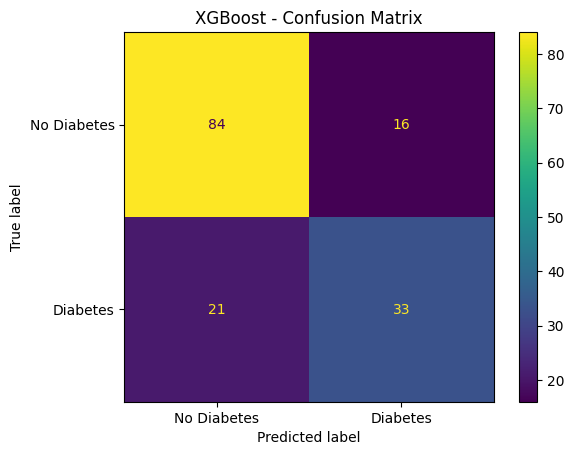

In [40]:
# STEP 26 - XGBoost Confusion Matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("XGBoost Confusion Matrix:")
print(cm_xgb)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()

plt.title("XGBoost - Confusion Matrix")
plt.show()

In [41]:
# STEP 27 - Compare All Models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_svm,
        accuracy_xgb
    ],

    "Precision": [
        precision_lr,
        precision_rf,
        precision_svm,
        precision_xgb
    ],

    "Recall": [
        recall_lr,
        recall_rf,
        recall_svm,
        recall_xgb
    ],

    "F1-Score": [
        f1_lr,
        f1_rf,
        f1_svm,
        f1_xgb
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_svm,
        roc_auc_xgb
    ]
})

print("=" * 90)
print("                 MODEL COMPARISON")
print("=" * 90)

display(results.round(4))

                 MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7143,0.6087,0.5185,0.5600,0.8230
1,Random Forest,0.7597,0.6809,0.5926,0.6337,0.8118
2,SVM,0.7532,0.6600,0.6111,0.6346,0.7924
3,XGBoost,0.7597,0.6735,0.6111,0.6408,0.8343


In [42]:
# Find the best model based on ROC-AUC

best_model = results.loc[
    results["ROC-AUC"].idxmax()
]

print("=" * 50)
print("              BEST MODEL")
print("=" * 50)

print("Model       :", best_model["Model"])
print("Accuracy    :", round(best_model["Accuracy"], 4))
print("Precision   :", round(best_model["Precision"], 4))
print("Recall      :", round(best_model["Recall"], 4))
print("F1-Score    :", round(best_model["F1-Score"], 4))
print("ROC-AUC     :", round(best_model["ROC-AUC"], 4))

print("=" * 50)

              BEST MODEL
Model       : XGBoost
Accuracy    : 0.7597
Precision   : 0.6735
Recall      : 0.6111
F1-Score    : 0.6408
ROC-AUC     : 0.8343


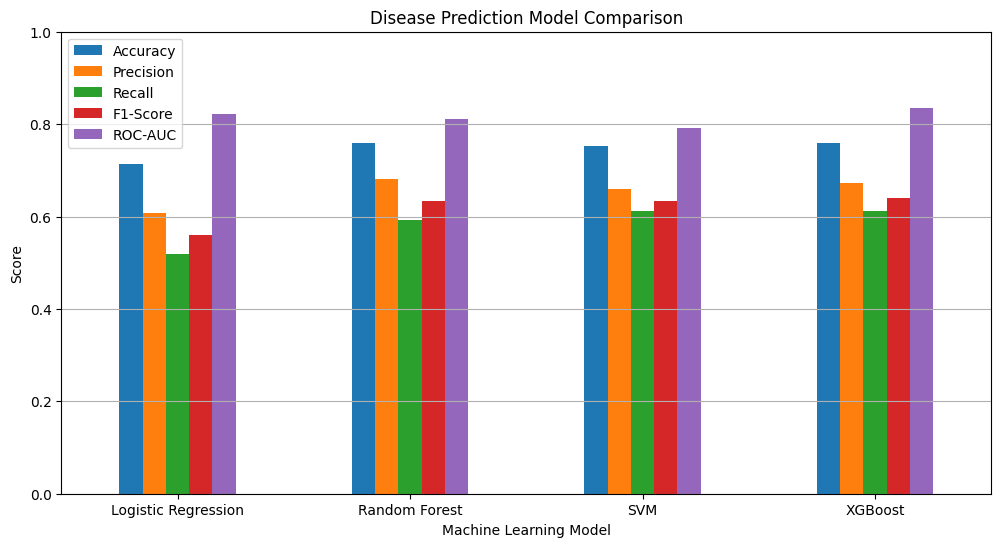

In [43]:
# Model Comparison Graph

results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Disease Prediction Model Comparison")
plt.ylabel("Score")
plt.xlabel("Machine Learning Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")
plt.show()

In [45]:
# STEP 28 - Final Disease Prediction

# Sample data for a new patient (replace with actual patient data)
# Make sure the order of features matches the training data (X)
new_patient_data = pd.DataFrame([[6, 148, 72, 35, 0, 33.6, 0.627, 50]], columns=X.columns)

# Get the best model name
best_model_name = results.loc[
    results["ROC-AUC"].idxmax(),
    "Model"
]

# Select the best model
if best_model_name == "Logistic Regression":
    final_model = logistic_model
    new_patient = scaler.transform(new_patient_data)

elif best_model_name == "Random Forest":
    final_model = random_forest
    new_patient = new_patient_data

elif best_model_name == "SVM":
    final_model = svm_model
    new_patient = scaler.transform(new_patient_data)

else:
    final_model = xgb_model
    new_patient = new_patient_data

# Reshape new_patient_data if it's not already 2D (e.g., for single prediction)
# This is important as models expect a 2D array, even for a single sample.
new_patient = new_patient.values.reshape(1, -1) if isinstance(new_patient, pd.DataFrame) else new_patient.reshape(1, -1)


# Make prediction
prediction = final_model.predict(new_patient)[0]

# Get probability
probability = final_model.predict_proba(new_patient)[0][1]

# Display result
print("=" * 55)
print("          FINAL DISEASE PREDICTION")
print("=" * 55)

print("Best Model :", best_model_name)

if prediction == 1:
    print("Prediction : Diabetes")
else:
    print("Prediction : No Diabetes")

print(f"Probability: {probability:.2%}")

print("=" * 55)


          FINAL DISEASE PREDICTION
Best Model : XGBoost
Prediction : Diabetes
Probability: 76.40%


In [46]:
# Sample patient information

new_patient_data = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [120],
    "BloodPressure": [70],
    "SkinThickness": [25],
    "Insulin": [80],
    "BMI": [28.5],
    "DiabetesPedigreeFunction": [0.35],
    "Age": [30]
})

print("New patient data:")
display(new_patient_data)

New patient data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,120,70,25,80,28.5,0.35,30


In [47]:
# STEP 29 - USER INPUT PREDICTION

print("=" * 60)
print("        DISEASE PREDICTION SYSTEM")
print("=" * 60)

# Get patient information
pregnancies = float(input("Enter number of Pregnancies: "))
glucose = float(input("Enter Glucose level: "))
blood_pressure = float(input("Enter Blood Pressure: "))
skin_thickness = float(input("Enter Skin Thickness: "))
insulin = float(input("Enter Insulin level: "))
bmi = float(input("Enter BMI: "))
diabetes_pedigree = float(input("Enter Diabetes Pedigree Function: "))
age = float(input("Enter Age: "))

# Create patient DataFrame
new_patient_data = pd.DataFrame({
    "Pregnancies": [pregnancies],
    "Glucose": [glucose],
    "BloodPressure": [blood_pressure],
    "SkinThickness": [skin_thickness],
    "Insulin": [insulin],
    "BMI": [bmi],
    "DiabetesPedigreeFunction": [diabetes_pedigree],
    "Age": [age]
})

# Select the best model from Step 27
best_model_name = results.loc[
    results["ROC-AUC"].idxmax(),
    "Model"
]

if best_model_name == "Logistic Regression":
    final_model = logistic_model
    patient_input = scaler.transform(new_patient_data)

elif best_model_name == "SVM":
    final_model = svm_model
    patient_input = scaler.transform(new_patient_data)

elif best_model_name == "Random Forest":
    final_model = random_forest
    patient_input = new_patient_data

else:
    final_model = xgb_model
    patient_input = new_patient_data

# Prediction
prediction = final_model.predict(patient_input)[0]
probability = final_model.predict_proba(patient_input)[0][1]

# Display result
print("\n" + "=" * 60)
print("             PREDICTION RESULT")
print("=" * 60)

print("Best Model :", best_model_name)

if prediction == 1:
    print("Prediction : Diabetes")
else:
    print("Prediction : No Diabetes")

print(f"Probability: {probability:.2%}")

print("=" * 60)

        DISEASE PREDICTION SYSTEM
Enter number of Pregnancies: 1000000
Enter Glucose level: 70
Enter Blood Pressure: 120
Enter Skin Thickness: 5
Enter Insulin level: 80
Enter BMI: 28.5
Enter Diabetes Pedigree Function: 90
Enter Age: 28

             PREDICTION RESULT
Best Model : XGBoost
Prediction : No Diabetes
Probability: 27.25%


In [48]:
# ============================================
# STEP 30 - FINAL PROJECT SUMMARY
# ============================================

print("=" * 65)
print("             DISEASE PREDICTION SYSTEM")
print("=" * 65)

print("\nPROJECT OBJECTIVE")
print("-----------------")
print("To predict the possibility of diabetes using")
print("machine learning algorithms and medical data.")

print("\nDATASET")
print("-------")
print("Pima Indians Diabetes Dataset")
print("Total Records : 768")
print("Total Features: 8")

print("\nFEATURES USED")
print("-------------")
print("1. Pregnancies")
print("2. Glucose")
print("3. Blood Pressure")
print("4. Skin Thickness")
print("5. Insulin")
print("6. BMI")
print("7. Diabetes Pedigree Function")
print("8. Age")

print("\nMACHINE LEARNING MODELS")
print("-----------------------")
print("1. Logistic Regression")
print("2. Random Forest")
print("3. Support Vector Machine (SVM)")
print("4. XGBoost")

print("\nMODEL EVALUATION")
print("----------------")
print("Accuracy")
print("Precision")
print("Recall")
print("F1-Score")
print("ROC-AUC")
print("Confusion Matrix")
print("ROC Curve")

print("\nBEST MODEL")
print("----------")
print("Best Model :", best_model_name)
print("ROC-AUC    :", round(best_roc_auc, 4) if 'best_roc_auc' in globals()
      else round(results['ROC-AUC'].max(), 4))

print("\nFINAL PREDICTION")
print("----------------")
if 'prediction' in globals():
    if prediction == 1:
        print("Prediction : Diabetes")
    else:
        print("Prediction : No Diabetes")

    print(f"Probability: {probability:.2%}")

print("\nCONCLUSION")
print("----------")
print("The Disease Prediction Model demonstrates how")
print("machine learning can be used to analyze medical")
print("data and predict diabetes outcomes.")
print("Different machine learning algorithms were")
print("compared using multiple evaluation metrics.")

print("\nFUTURE SCOPE")
print("------------")
print("1. Use larger and more diverse medical datasets")
print("2. Add more relevant medical features")
print("3. Improve model performance")
print("4. Develop a web-based application")
print("5. Add Explainable AI")
print("6. Continuously monitor model performance")

print("\n" + "=" * 65)
print("             PROJECT COMPLETED")
print("=" * 65)

             DISEASE PREDICTION SYSTEM

PROJECT OBJECTIVE
-----------------
To predict the possibility of diabetes using
machine learning algorithms and medical data.

DATASET
-------
Pima Indians Diabetes Dataset
Total Records : 768
Total Features: 8

FEATURES USED
-------------
1. Pregnancies
2. Glucose
3. Blood Pressure
4. Skin Thickness
5. Insulin
6. BMI
7. Diabetes Pedigree Function
8. Age

MACHINE LEARNING MODELS
-----------------------
1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)
4. XGBoost

MODEL EVALUATION
----------------
Accuracy
Precision
Recall
F1-Score
ROC-AUC
Confusion Matrix
ROC Curve

BEST MODEL
----------
Best Model : XGBoost
ROC-AUC    : 0.823

FINAL PREDICTION
----------------
Prediction : No Diabetes
Probability: 27.25%

CONCLUSION
----------
The Disease Prediction Model demonstrates how
machine learning can be used to analyze medical
data and predict diabetes outcomes.
Different machine learning algorithms were
compared using multiple ev